In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/iasadpanwhar/parking-lot-detection-counter/parking/mask_crop.png
/kaggle/input/datasets/iasadpanwhar/parking-lot-detection-counter/parking/parking_1920_1080_loop.mp4
/kaggle/input/datasets/iasadpanwhar/parking-lot-detection-counter/parking/mask_1920_1080.png
/kaggle/input/datasets/iasadpanwhar/parking-lot-detection-counter/parking/parking_crop_loop.mp4
/kaggle/input/datasets/iasadpanwhar/parking-lot-detection-counter/parking/parking_1920_1080.mp4
/kaggle/input/datasets/iasadpanwhar/parking-lot-detection-counter/parking/util.py
/kaggle/input/datasets/iasadpanwhar/parking-lot-detection-counter/parking/parking_crop.mp4
/kaggle/input/datasets/iasadpanwhar/parking-lot-detection-counter/parking/model/model.p
/kaggle/input/datasets/iasadpanwhar/parking-lot-detection-counter/parking/clf-data/empty/00000610_00000385.jpg
/kaggle/input/datasets/iasadpanwhar/parking-lot-detection-counter/parking/clf-data/empty/00000590_00000180.jpg
/kaggle/input/datasets/iasadpanwhar/parking

# SETUP : import module, device configuration, path configuration

In [2]:
import os
import cv2
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import warnings

from ultralytics import YOLO

# Import PyTorch dan Torchvision
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import transforms, models
from torchvision.datasets import ImageFolder

warnings.filterwarnings("ignore")

# Konfigurasi Device
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Perangkat yang digunakan: {DEVICE}")


# Konfigurasi path
DATA_DIR = '/kaggle/input/datasets/iasadpanwhar/parking-lot-detection-counter/parking'

df_training_empty = os.path.join(DATA_DIR, 'clf-data', 'empty')
df_training_full = os.path.join(DATA_DIR, 'clf-data', 'not_empty')

mask_full = os.path.join(DATA_DIR, 'mask_1920_1080.png')
mask_crop = os.path.join(DATA_DIR, 'mask_crop.png')

parking_full = os.path.join(DATA_DIR, 'parking_1920_1080.mp4')
parking_full_loop = os.path.join(DATA_DIR, 'parking_1920_1080_loop.mp4')
parking_crop = os.path.join(DATA_DIR, 'parking_crop.mp4')
parking_crop_loop = os.path.join(DATA_DIR, 'parking_crop_loop.mp4')

BASE_WORKING_DIR = "/kaggle/working/"
DATASET_SPLIT_DIR = os.path.join(BASE_WORKING_DIR, "datasets")
OUTPUT_VIDEO_PATH = os.path.join(BASE_WORKING_DIR, "output_video.mp4")
MODEL_SAVE_PATH = os.path.join(BASE_WORKING_DIR, "parking_model.pth")

print("setup selesai")

Perangkat yang digunakan: cuda
setup selesai


# 1. Explore dataset

In [3]:
# Memeriksa jumlah data
train_images_empty = sorted(os.listdir(df_training_empty))
train_images_full = sorted(os.listdir(df_training_full))

print(f"Jumlah Gambar Training tempat parkir yang berstatus kosong: {len(train_images_empty)}")
print(f"Jumlah Gambar Training tempat parkir yang ber status full: {len(train_images_full)}", end="\n\n")


# memeriksa ukuran gambar
from PIL import Image

print ('ukuran gambar data parkiran empty (dalam width, height): ')
for img_name in train_images_empty[:10]:
    path = os.path.join(df_training_empty, img_name)
    with Image.open(path) as img:
        print(img_name, img.size)  # (width, height)
print()

print ('ukuran gambar data parkiran full (dalam width, height) : ')
for img_name in train_images_full[:10]:
    path = os.path.join(df_training_full, img_name)
    with Image.open(path) as img:
        print(img_name, img.size)

Jumlah Gambar Training tempat parkir yang berstatus kosong: 3045
Jumlah Gambar Training tempat parkir yang ber status full: 3045

ukuran gambar data parkiran empty (dalam width, height): 
00000000_00000161.jpg (69, 29)
00000000_00000164.jpg (69, 29)
00000000_00000179.jpg (69, 31)
00000000_00000180.jpg (68, 31)
00000000_00000185.jpg (68, 31)
00000000_00000201.jpg (68, 29)
00000000_00000223.jpg (60, 29)
00000000_00000224.jpg (68, 27)
00000000_00000271.jpg (68, 28)
00000000_00000280.jpg (68, 30)

ukuran gambar data parkiran full (dalam width, height) : 
00000000_00000003.jpg (64, 35)
00000000_00000005.jpg (61, 26)
00000000_00000007.jpg (71, 31)
00000000_00000013.jpg (61, 30)
00000000_00000014.jpg (69, 26)
00000000_00000016.jpg (62, 31)
00000000_00000017.jpg (72, 26)
00000000_00000018.jpg (68, 27)
00000000_00000028.jpg (69, 27)
00000000_00000031.jpg (68, 27)


# 2. Data augmentation
(sebenernya opsional karena YOLO udah otomatis melakukan augmentasi)  (beneran ngga kepake cik)

In [4]:
IMG_SIZE = 224 

# 1. Transformasi untuk Data Training (Dengan Augmentasi)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(15), 
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    # Normalisasi standar ImageNet
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

# 2. Transformasi untuk Data Validation & Test (TANPA Augmentasi)
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 3. Simpan dalam dictionary agar mudah dipanggil saat loading dataset
data_transforms = {
    'train': train_transform,
    'val': val_test_transform,
    'test': val_test_transform
}

print(f"Transformasi dan augmentasi berhasil didefinisikan!")
print(f"Ukuran gambar diatur menjadi: {IMG_SIZE}x{IMG_SIZE}")

Transformasi dan augmentasi berhasil didefinisikan!
Ukuran gambar diatur menjadi: 224x224


# 3. Split datasetnya

In [5]:
def split_data(source_dir, class_name, split_dir, train_ratio=0.7, val_ratio=0.2):
    if not os.path.exists(source_dir):
        print(f"Melewati {class_name}, direktori sumber tidak ditemukan: {source_dir}")
        return

    # Buat direktori target
    for split in ['train', 'val', 'test']:
        os.makedirs(os.path.join(split_dir, split, class_name), exist_ok=True)

    # Ambil semua file gambar dan acak urutannya
    images = [f for f in os.listdir(source_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    random.seed(42)
    random.shuffle(images)

    # Hitung indeks pemotongan
    total_images = len(images)
    train_end = int(total_images * train_ratio)
    val_end = train_end + int(total_images * val_ratio)

    # Pisahkan daftar file
    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    # Fungsi bantuan untuk menyalin file
    def copy_files(file_list, split_name):
        target_dir = os.path.join(split_dir, split_name, class_name)
        for file in tqdm(file_list, desc=f"Copying {class_name} to {split_name}", leave=False):
            src = os.path.join(source_dir, file)
            dst = os.path.join(target_dir, file)
            shutil.copy(src, dst)

    # Eksekusi penyalinan
    copy_files(train_images, 'train')
    copy_files(val_images, 'val')
    copy_files(test_images, 'test')
    
    print(f"[{class_name.upper()}] Selesai! Train: {len(train_images)} | Val: {len(val_images)} | Test: {len(test_images)}")

# Eksekusi split untuk kedua kelas
print("Memulai proses pemisahan dataset...")
# Pastikan folder utama datasets bersih jika cell ini dijalankan ulang
if os.path.exists(DATASET_SPLIT_DIR):
    shutil.rmtree(DATASET_SPLIT_DIR)

split_data(df_training_empty, "empty", DATASET_SPLIT_DIR)
split_data(df_training_full, "not_empty", DATASET_SPLIT_DIR)
print(f"\nStruktur dataset berhasil dibuat di: {DATASET_SPLIT_DIR}")

Memulai proses pemisahan dataset...


Copying empty to train:   0%|          | 0/2131 [00:00<?, ?it/s]

Copying empty to val:   0%|          | 0/609 [00:00<?, ?it/s]

Copying empty to test:   0%|          | 0/305 [00:00<?, ?it/s]

[EMPTY] Selesai! Train: 2131 | Val: 609 | Test: 305


Copying not_empty to train:   0%|          | 0/2131 [00:00<?, ?it/s]

Copying not_empty to val:   0%|          | 0/609 [00:00<?, ?it/s]

Copying not_empty to test:   0%|          | 0/305 [00:00<?, ?it/s]

[NOT_EMPTY] Selesai! Train: 2131 | Val: 609 | Test: 305

Struktur dataset berhasil dibuat di: /kaggle/working/datasets


# 4. Model


Memulai proses training pada device: 0...
Ultralytics 8.4.89 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/datasets, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26_parking_classifier-2, nbs=64, nms=False, opset=None

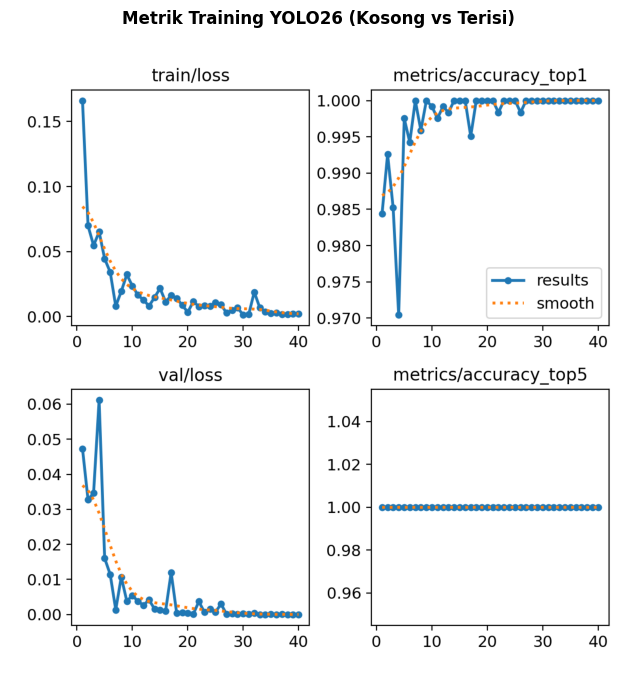

In [6]:
model = YOLO('yolo26n-cls.pt')

# 2. Konfigurasi parameter training
EPOCHS = 40
IMG_SIZE = 224
PROJECT_DIR = BASE_WORKING_DIR  # /kaggle/working/
RUN_NAME = "yolo26_parking_classifier"
device_yolo = 0 if torch.cuda.is_available() else 'cpu'

print(f"\nMemulai proses training pada device: {device_yolo}...") 
results = model.train(
    data=DATASET_SPLIT_DIR,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    project=PROJECT_DIR,
    name=RUN_NAME,
    device=device_yolo,
)

# 4. Mendapatkan path model terbaik
best_model_path = os.path.join(PROJECT_DIR, RUN_NAME, "weights", "best.pt")
print(f"\n Training selesai!")
print(f" Model terbaik (best.pt) berhasil disimpan di: {best_model_path}")

# 5. Menampilkan Grafik Hasil Evaluasi (Loss, Akurasi, dll)
results_img_path = os.path.join(PROJECT_DIR, RUN_NAME, "results.png")

if os.path.exists(results_img_path):
    img = Image.open(results_img_path)
    plt.figure(figsize=(16, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Metrik Training YOLO26 (Kosong vs Terisi)', pad=20, fontweight='bold')
    plt.show()
else:
    print("Grafik hasil training belum tersedia.")

# 5. evaluasi

# 5. Evaluasi

In [7]:
best_model = YOLO(best_model_path)

# split='test' memberitahu YOLO untuk menggunakan folder 'test' 
metrics = best_model.val(data=DATASET_SPLIT_DIR, split='test')

print("\nEvaluasi Selesai!")
print(f"Top-1 Accuracy pada Data Test: {metrics.top1:.4f}")

Ultralytics 8.4.89 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26n-cls summary (fused): 47 layers, 1,528,586 parameters, 0 gradients, 3.2 GFLOPs
train: /kaggle/working/datasets/train... found 4262 images in 2 classes ✅ 
val: /kaggle/working/datasets/val... found 1218 images in 2 classes ✅ 
test: /kaggle/working/datasets/test... found 610 images in 2 classes ✅ 
WARNING ⚠️ test: Slow image access detected (ping: 0.0±0.0 ms, read: 45.6±19.2 MB/s, size: 1.2 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
test: Scanning /kaggle/working/datasets/test... 610 images, 0 corrupt: 100% ━━━━━━━━━━━━ 610/610 2.7Kit/s 0.2s0.0ss
test: New cache created: /kaggle/working/datasets/test.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 39/39 32.1it/s 1.2s0.1s
                   all          1          1
Speed: 0.1ms preprocess, 1.1ms inference, 0.0ms loss, 0.0ms postpr

# 6. Pemrosesan video

In [8]:
# 1. Ekstrak Koordinat Parkir dari Gambar Masking
print("Membaca data masking untuk mengekstrak area parkir...")
mask = cv2.imread(mask_full, cv2.IMREAD_GRAYSCALE)
if mask is None:
    raise ValueError(f"Gambar masking tidak ditemukan di: {mask_full}")

# Mencari kontur pada masking (area parkir berwarna putih dan background hitam)
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Ubah kontur menjadi bounding box (x, y, w, h)
# Filter area kecil ( < 100 piksel) untuk mengabaikan noise
parking_slots = [cv2.boundingRect(c) for c in contours if cv2.contourArea(c) > 100]
print(f" Ditemukan {len(parking_slots)} slot parkir dari gambar masking.")

# 2. Setup Video Input & Output
cap = cv2.VideoCapture(parking_full)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

# Codec mp4v aman digunakan pada lingkungan Kaggle/Linux        (audit lagi ini)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(OUTPUT_VIDEO_PATH, fourcc, fps, (width, height))

# Load class names dari model untuk mapping output YOLO
class_names = best_model.names 
print(f"Mapping kelas YOLO: {class_names}")

print("\nMemulai pemrosesan video frame-by-frame... (Silakan tunggu)")

frame_count = 0
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
        
    frame_count += 1
    empty_count = 0
    occupied_count = 0
    
    # 3. Crop area parkir pada frame saat ini
    crops = []
    for (x, y, w, h) in parking_slots:
        crop = frame[y:y+h, x:x+w]
        crops.append(crop)
        
    # 4. Prediksi keseluruhan crop dalam satu Batch (lebih cepat)
    # verbose=False agar output console tidak banjir log di setiap frame
    results = best_model(crops, verbose=False)
    
    # 5. Gambar visualisasi berdasarkan hasil prediksi
    for i, result in enumerate(results):
        x, y, w, h = parking_slots[i]
        
        # Ambil nama kelas dengan probabilitas tertinggi (top-1)
        top_class_id = result.probs.top1
        predicted_class = class_names[top_class_id]
        
        # Tentukan warna dan update counter
        if predicted_class == 'empty':
            color = (0, 255, 0) # Hijau untuk Kosong
            empty_count += 1
        else:
            color = (0, 0, 255) # Merah untuk Terisi
            occupied_count += 1
            
        # Gambar Bounding Box di frame utama
        cv2.rectangle(frame, (x, y), (x+w, y+h), color, 2)
        
    # 6. Buat Overlay Background Semi-Transparan untuk Teks Counter
    overlay = frame.copy()
    cv2.rectangle(overlay, (10, 10), (350, 110), (0, 0, 0), -1)
    # Gabungkan overlay dengan frame asli (transparansi 60%)
    cv2.addWeighted(overlay, 0.6, frame, 0.4, 0, frame)
    
    # Tulis teks counter
    cv2.putText(frame, f"KOSONG : {empty_count}", (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 3)
    cv2.putText(frame, f"TERISI : {occupied_count}", (20, 90), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 3)
    
    # Tulis frame ke file output
    out.write(frame)
    
    # Cetak progress setiap 50 frame (biar ga banjir log ae sih)
    if frame_count % 50 == 0:
        print(f"Memproses frame {frame_count}/{total_frames}...")
    
# Bersihkan memori
cap.release()
out.release()
print(f"\nPemrosesan video berhasil diselesaikan!")
print(f"Video output disimpan di: {OUTPUT_VIDEO_PATH}")

Membaca data masking untuk mengekstrak area parkir...
 Ditemukan 396 slot parkir dari gambar masking.
Mapping kelas YOLO: {0: 'empty', 1: 'not_empty'}

Memulai pemrosesan video frame-by-frame... (Silakan tunggu)
Memproses frame 50/849...
Memproses frame 100/849...
Memproses frame 150/849...
Memproses frame 200/849...
Memproses frame 250/849...
Memproses frame 300/849...
Memproses frame 350/849...
Memproses frame 400/849...
Memproses frame 450/849...
Memproses frame 500/849...
Memproses frame 550/849...
Memproses frame 600/849...
Memproses frame 650/849...
Memproses frame 700/849...
Memproses frame 750/849...
Memproses frame 800/849...

Pemrosesan video berhasil diselesaikan!
Video output disimpan di: /kaggle/working/output_video.mp4


# 7. Tampilkan Frame Sample dengan Overlay

Mengambil sample frame dari: /kaggle/working/output_video.mp4


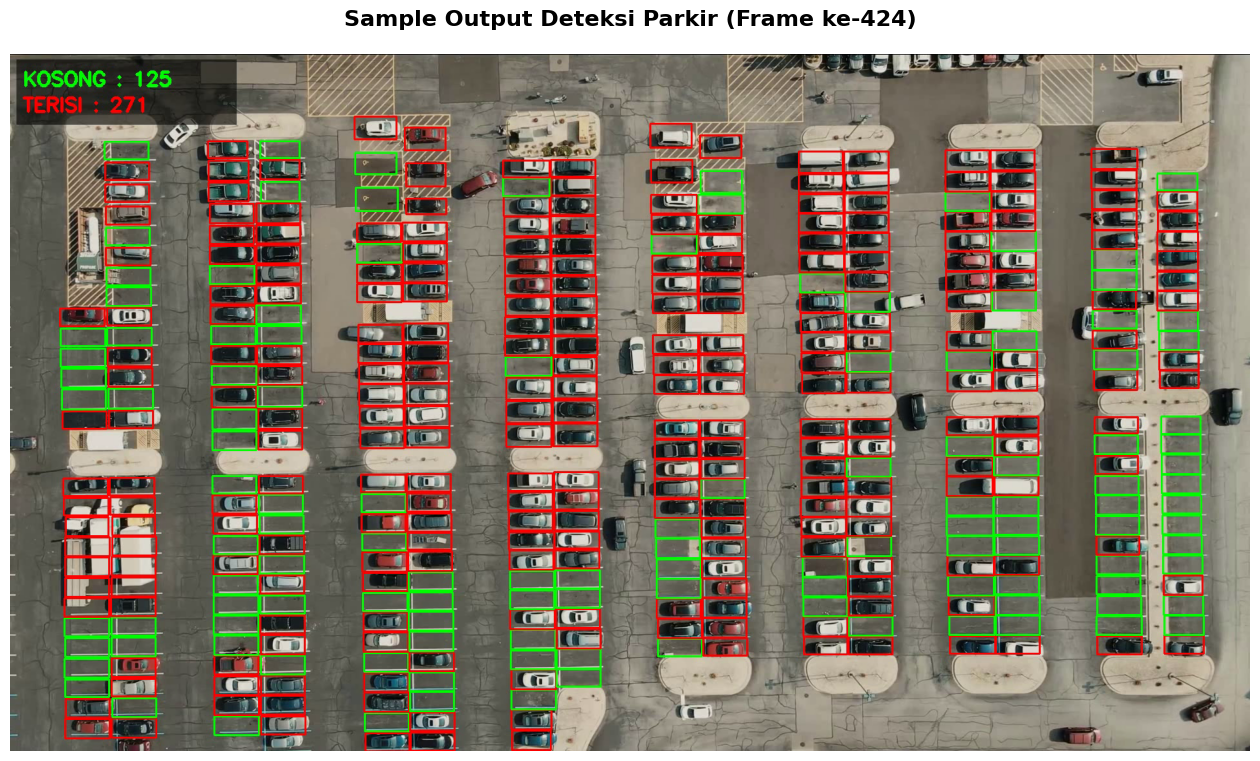

In [9]:
print(f"Mengambil sample frame dari: {OUTPUT_VIDEO_PATH}")

# 1. Buka video output hasil proses Cell 6
cap_out = cv2.VideoCapture(OUTPUT_VIDEO_PATH)

if not cap_out.isOpened():
    print("Error: Tidak dapat membuka video output. Pastikan Cell 7 sudah selesai dijalankan.")
else:
    # 2. Ambil total frame untuk memilih frame di pertengahan video
    total_frames = int(cap_out.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Kita ambil frame di pertengahan video agar terlihat area parkir yang sudah ada isinya
    target_frame = total_frames // 2 
    cap_out.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
    
    # 3. Baca frame
    ret, frame = cap_out.read()
    cap_out.release()
    
    if ret:
        # 4. Konversi BGR (OpenCV) ke RGB (Matplotlib)
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # 5. Tampilkan gambar
        plt.figure(figsize=(16, 10))
        plt.imshow(frame_rgb)
        plt.axis('off') # Sembunyikan sumbu X dan Y
        plt.title(f'Sample Output Deteksi Parkir (Frame ke-{target_frame})', pad=20, fontsize=16, fontweight='bold')
        
        # Tampilkan hasil akhir di cell output Kaggle
        plt.show()
    else:
        print("Gagal membaca frame dari video output. File mungkin rusak atau kosong.")

